Dataset Overview

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# Path to your datasets
DATASET_PATH = Path("../data/raw/MachineLearningCVE")

# Find every CSV file
csv_files = sorted(DATASET_PATH.glob("*.csv"))

summary = []

print("=" * 80)
print(f"Found {len(csv_files)} CSV files")
print("=" * 80)

for file in csv_files:

    print(f"\n{'='*80}")
    print(f"Dataset: {file.name}")
    print("=" * 80)

    df = pd.read_csv(file)

    rows, cols = df.shape

    missing = df.isnull().sum().sum()

    duplicates = df.duplicated().sum()

    numeric_df = df.select_dtypes(include=[np.number])
    infinite = np.isinf(numeric_df).sum().sum()

    labels = df[" Label"].value_counts()

    print(f"Rows           : {rows:,}")
    print(f"Columns        : {cols}")
    print(f"Missing values : {missing}")
    print(f"Duplicates     : {duplicates}")
    print(f"Infinite values: {infinite}")

    print("Attack distribution:")
    print(labels)

    summary.append({
        "Dataset": file.name,
        "Rows": rows,
        "Columns": cols,
        "Missing Values": missing,
        "Infinite Values": infinite,
        "Duplicates": duplicates,
        "Classes": ", ".join(labels.index.astype(str)),
        "Number of Classes": len(labels)
    })

summary_df = pd.DataFrame(summary)

print("\n")
print("=" * 80)
print("SUMMARY")
print("=" * 80)

display(summary_df)

Found 8 CSV files

Dataset: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Rows           : 225,745
Columns        : 79
Missing values : 4
Duplicates     : 2633
Infinite values: 64

Attack distribution:
 Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

Dataset: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Rows           : 286,467
Columns        : 79
Missing values : 15
Duplicates     : 72353
Infinite values: 727

Attack distribution:
 Label
PortScan    158930
BENIGN      127537
Name: count, dtype: int64

Dataset: Friday-WorkingHours-Morning.pcap_ISCX.csv
Rows           : 191,033
Columns        : 79
Missing values : 28
Duplicates     : 6888
Infinite values: 216

Attack distribution:
 Label
BENIGN    189067
Bot         1966
Name: count, dtype: int64

Dataset: Monday-WorkingHours.pcap_ISCX.csv
Rows           : 529,918
Columns        : 79
Missing values : 64
Duplicates     : 26935
Infinite values: 810

Attack distribution:
 Label
BENIGN    529918
Name: count, dt

,Dataset,Rows,Columns,Missing Values,Infinite Values,Duplicates,Classes,Number of Classes
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,225745,79,4,64,2633,"DDoS, BENIGN",2
1,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,286467,79,15,727,72353,"PortScan, BENIGN",2
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,191033,79,28,216,6888,"BENIGN, Bot",2
3,Monday-WorkingHours.pcap_ISCX.csv,529918,79,64,810,26935,BENIGN,1
4,Thursday-WorkingHours-Afternoon-Infilteration....,288602,79,18,396,35630,"BENIGN, Infiltration",2
5,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,170366,79,20,250,6066,"BENIGN, Web Attack � Brute Force, Web Attack �...",4
6,Tuesday-WorkingHours.pcap_ISCX.csv,445909,79,201,327,24065,"BENIGN, FTP-Patator, SSH-Patator",3
7,Wednesday-workingHours.pcap_ISCX.csv,692703,79,1008,1586,81909,"BENIGN, DoS Hulk, DoS GoldenEye, DoS slowloris...",6


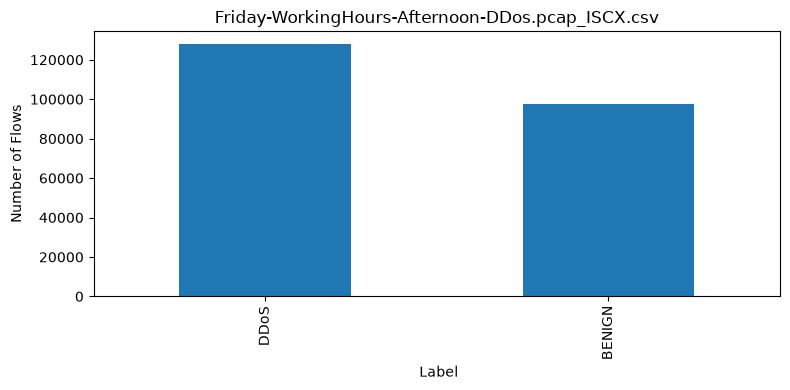

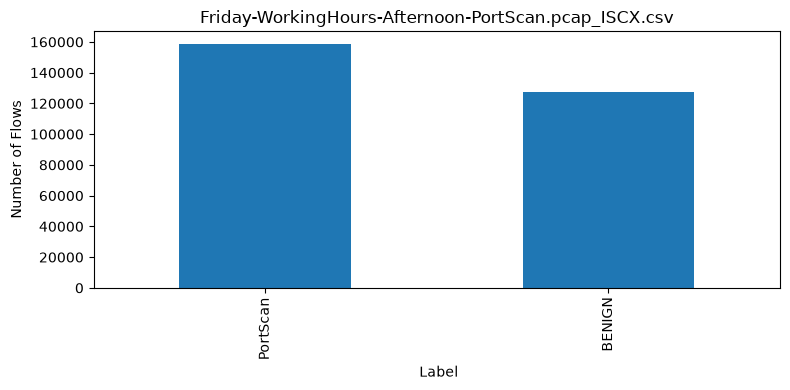

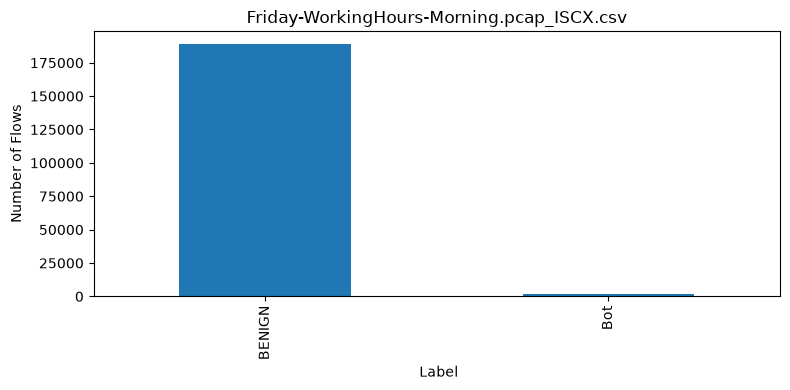

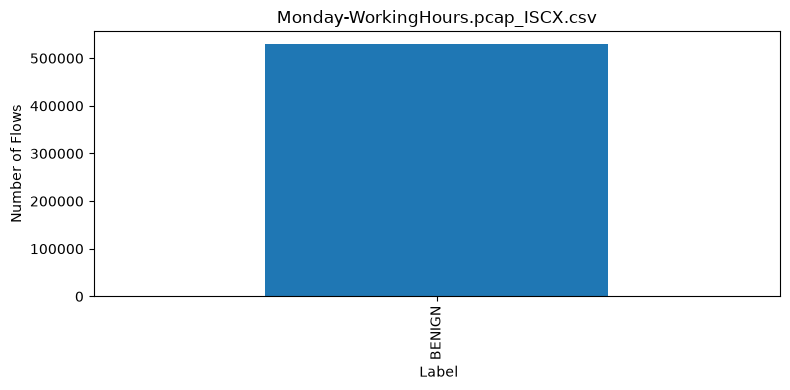

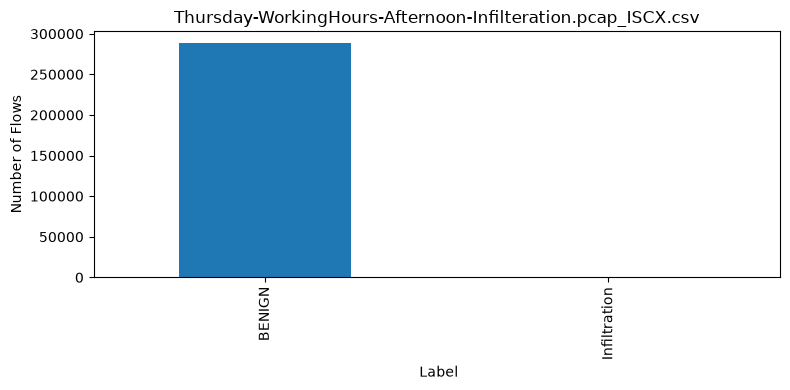

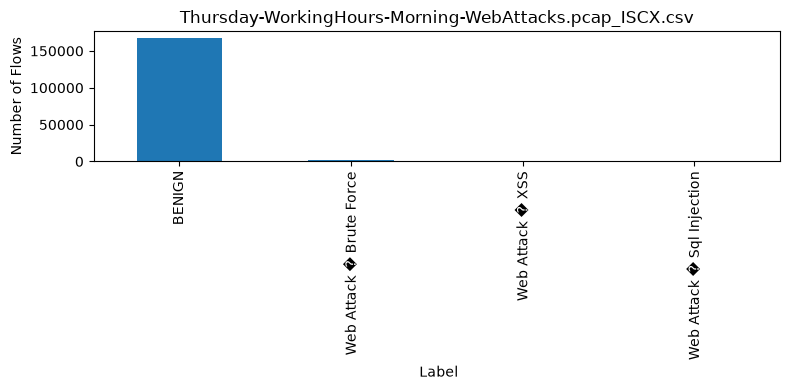

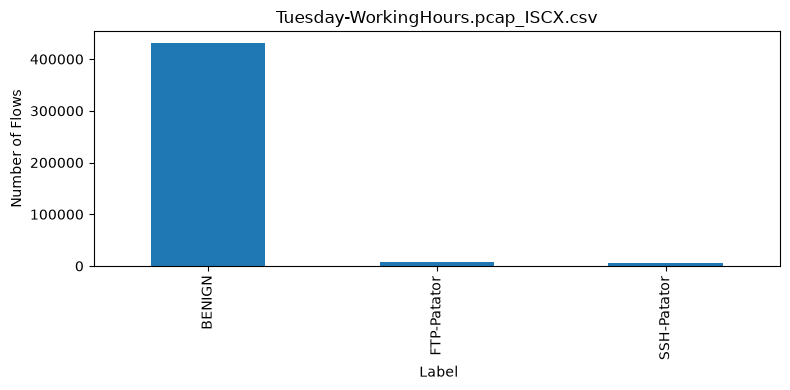

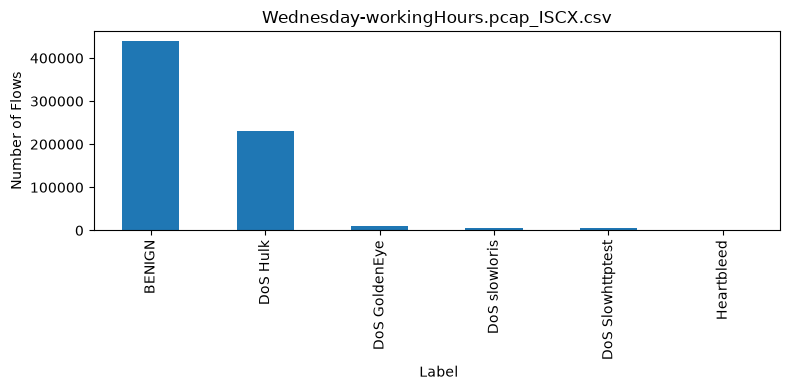

In [7]:
import matplotlib.pyplot as plt

for file in csv_files:

    df = pd.read_csv(file)

    plt.figure(figsize=(8,4))

    df[" Label"].value_counts().plot(kind="bar")

    plt.title(file.name)
    plt.ylabel("Number of Flows")

    plt.tight_layout()
    plt.show()

In [8]:
summary_df.to_excel("../reports/dataset_summary.xlsx", index=False)

print("Summary exported successfully!")

Summary exported successfully!


In [9]:
print(f"Total rows: {summary_df['Rows'].sum():,}")

Total rows: 2,830,743


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_PATH = "../data/raw/MachineLearningCVE"

csv_files = sorted(DATASET_PATH.glob("*.csv"))

summary = []

for file in csv_files:

    df = pd.read_csv(file)
    raws, cols = df.shape

    missing = df.isnull().sum().sum()
    infinites = np.isinf(numeric_df).sum().sum()
    duplicates = df.duplicated().sum()
    labels = df[" Label"].value_counts()

    print("Data set overview :")
    print(f"Raws :{raws :,}")
    print(f"Columns :{cols}")
    print(f"Missing values : {missing}")
    print(f"Infinites values : {infinites}")
    print(f"Duplicates : { duplicates }")

    print("\nAttack distribusion")
    print(labels)

    summary.append({
        "Dataset": file.name,
        "Rows": rows,
        "Cols": cols,
        "missing": missing,
        "infinites": infinites,
        "duplicates":duplicates,
    })
df_summary = pd.DataFrame(summary)
print("Summary display :\n")
display(df_summary)


Data set overview :
Raws :225,745
Columns :79
Missing values : 4
Infinites values : 1586
Duplicates : 2633

Attack distribusion
 Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64
Data set overview :
Raws :286,467
Columns :79
Missing values : 15
Infinites values : 1586
Duplicates : 72353

Attack distribusion
 Label
PortScan    158930
BENIGN      127537
Name: count, dtype: int64
Data set overview :
Raws :191,033
Columns :79
Missing values : 28
Infinites values : 1586
Duplicates : 6888

Attack distribusion
 Label
BENIGN    189067
Bot         1966
Name: count, dtype: int64
Data set overview :
Raws :529,918
Columns :79
Missing values : 64
Infinites values : 1586
Duplicates : 26935

Attack distribusion
 Label
BENIGN    529918
Name: count, dtype: int64
Data set overview :
Raws :288,602
Columns :79
Missing values : 18
Infinites values : 1586
Duplicates : 35630

Attack distribusion
 Label
BENIGN          288566
Infiltration        36
Name: count, dtype: int64
Data set overview :

,Dataset,Rows,Cols,missing,infinites,duplicates
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,692703,79,4,1586,2633
1,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,692703,79,15,1586,72353
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,692703,79,28,1586,6888
3,Monday-WorkingHours.pcap_ISCX.csv,692703,79,64,1586,26935
4,Thursday-WorkingHours-Afternoon-Infilteration....,692703,79,18,1586,35630
5,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,692703,79,20,1586,6066
6,Tuesday-WorkingHours.pcap_ISCX.csv,692703,79,201,1586,24065
7,Wednesday-workingHours.pcap_ISCX.csv,692703,79,1008,1586,81909
